#### Group: Juan Cisneros jc222256, Sarah Rincon sr56495, Juan Arellano jma6353

#### Section 1: Review of Part 2

In Part 2, we solved a stiff ordinary differential equation that modeled a chemical reaction approaching equilibrium. The governing equation was: $\frac{dy}{dt} = -\lambda y + \lambda y_{eq}(t)$, where $y(t)$ represents the chemical concentration and $y_{eq}(t)$ represents the equilibrium concentration. The stiffness parameter was $\lambda$ = 10^4, which means the reaction changes very quickly compared to the slower eqilibrium function.

This problem is stiff because it has both fast and slow behavior. The large value of λ creates a very fast reaction time scale, while the equilibrium function changes slowly over time. In Part 2, Forward Euler required a step size smaller than about 2/λ=0.0002 to stay stable. Because this would require many steps, Forward Euler was inefficient. Backward Euler was more effective because it stayed stable with larger step sizes.

#### Section 2: Newton- Raphson Damping Implementation

In Part 2, Backward Euler required solving an implicit equation at every time step. This was done using the Newton-Raphson method. Basic Newton-Raphson works by taking a full update step based on the residual and its derivative. This works well when the initial guess is close to the correct solution, but it can fail if the step size is large or if the Newton update overshoots.

To improve this, damped Newton-Raphson uses a damping factor α. The method starts with α=1, which is the normal Newton-Raphson step. If the residual does not decrease, α is cut in half until the step improves the residual. This process is called a line search. Damping makes the solver more stable because it only accepts steps that reduce the residual.

In [13]:
import numpy as np

# Parameters from Part 2
lam = 1e4
y0 = 0
t0 = 0
tf = 10

# Equilibrium function
def y_eq(t):
    return 1 + 0.1*np.sin(0.1*t)

# ODE
def f(t, y):
    return -lam*y + lam*y_eq(t)

# derivative wrt y
def dfdy(t, y):
    return -lam

def basic_newton_step(y_n, t_next, h, tol=1e-8, max_iter=20):
    y_guess = y_n + h*f(t_next, y_n)

    for i in range(max_iter):
        g = y_guess - y_n - h*f(t_next, y_guess)
        g_prime = 1 - h*dfdy(t_next, y_guess)

        y_new = y_guess - g/g_prime

        if abs(y_new - y_guess) < tol:
            return y_new, i + 1, True

        y_guess = y_new

    return y_guess, max_iter, False

def damped_newton_step(y_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n + h*f(t_next, y_n)

    total_backtracks = 0
    final_alpha = 1
    damping_used = False

    for i in range(max_iter):
        g = y_guess - y_n - h*f(t_next, y_guess)
        g_prime = 1 - h*dfdy(t_next, y_guess)

        delta = -g/g_prime
        alpha = 1.0
        old_residual = abs(g)

        while alpha > alpha_min:
            y_trial = y_guess + alpha*delta
            g_trial = y_trial - y_n - h*f(t_next, y_trial)

            if abs(g_trial) < old_residual:
                break

            alpha = alpha/2
            total_backtracks += 1
            damping_used = True

        if alpha <= alpha_min:
            return y_guess, i + 1, False, total_backtracks, alpha, damping_used

        y_new = y_guess + alpha*delta
        final_alpha = alpha

        if abs(y_new - y_guess) < tol:
            return y_new, i + 1, True, total_backtracks, final_alpha, damping_used

        y_guess = y_new

    return y_guess, max_iter, False, total_backtracks, final_alpha, damping_used

# Demonstration of basic NR vs damped NR with a large step size
h_test = 1.0
t_next = t0 + h_test

basic_result = basic_newton_step(y0, t_next, h_test)
damped_result = damped_newton_step(y0, t_next, h_test)

comparison = pd.DataFrame({
    "Method": ["Basic Newton-Raphson", "Damped Newton-Raphson"],
    "Solution": [basic_result[0], damped_result[0]],
    "Iterations": [basic_result[1], damped_result[1]],
    "Converged": [basic_result[2], damped_result[2]],
    "Backtracking Steps": ["N/A", damped_result[3]],
    "Final Alpha": ["N/A", damped_result[4]],
    "Damping Used": ["N/A", damped_result[5]]
})

comparison

,Method,Solution,Iterations,Converged,Backtracking Steps,Final Alpha,Damping Used
0,Basic Newton-Raphson,1.009882,2,True,N/A,N/A,N/A
1,Damped Newton-Raphson,1.009882,2,True,0,1,False


For this specific system, Newton-Raphson usually converges quickly because the equation is linear in y. Because of that, damping may not always be required. However, the damped version is still better for robustness because it checks whether each Newton step actually reduces the residual. This makes the solver safer for larger step sizes, poor initial guesses, or more nonlinear stiff systems.

#### Section 3: Adaptive Step Size Implementation

Adaptive step size control automatically changes the step size based on the estimated error. This is useful because a fixed step size can waste computation if it is too small, or give inaccurate results if it is too large. Instead of using one value of h for the entire solution, the adaptive method adjusts h as the solution changes.

The method used here is step-doubling. For each attempted step, the solver computes one Backward Euler step of size h, then computes two smaller Backward Euler steps of size h/2. The difference between these two results is used as the error estimate:

            $$\text{err} = \left| y_{h/2} - y_h \right|$$
            
If the error is less than the tolerance, the step is accepted. If the error is greater than the tolerance, the step is rejected and repeated with a smaller step size.

{'accepted_steps': 124, 'rejected_steps': 8, 'nr_iterations': 792, 'damping_used': 117, 'function_evals': 792, 'total_backtracks': 4774}


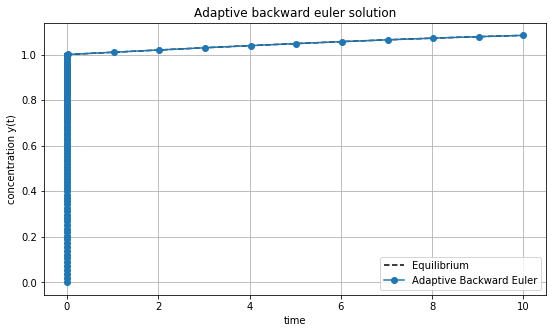

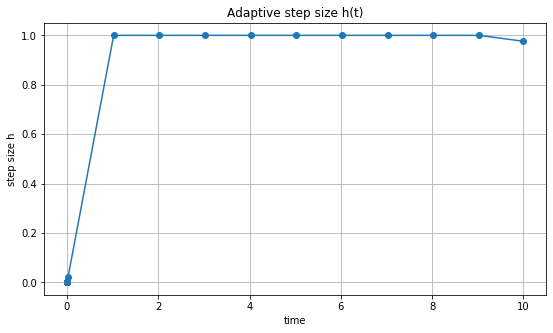

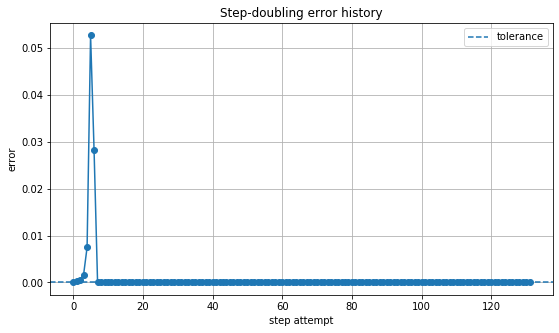

In [11]:
import numpy as np
import matplotlib.pyplot as plt
def backward_euler_single_step(y_n, t_n, h, use_damping=True):
    t_next = t_n + h

    if use_damping:
        y_next, iterations, converged, backtracks, alpha, damping_used = damped_newton_step(
            y_n, t_next, h
        )

        info = {
            "iterations": iterations,
            "converged": converged,
            "backtracks": backtracks,
            "alpha": alpha,
            "damping_used": damping_used
        }

    else:
        y_next, iterations, converged = basic_newton_step(y_n, t_next, h)

        info = {
            "iterations": iterations,
            "converged": converged,
            "backtracks": 0,
            "alpha": 1,
            "damping_used": False
        }

    return y_next, info
def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol,
                            h_min=1e-6, h_max=1.0, safety=0.9):

    # store solution values
    t_values = [t0]
    y_values = [y0]

    # store tracking information
    h_history = []
    error_history = []
    accepted_history = []

    h = h0
    t = t0
    y = y0

    stats = {
        "accepted_steps": 0,
        "rejected_steps": 0,
        "nr_iterations": 0,
        "damping_used": 0,
        "function_evals": 0,
        "total_backtracks": 0
    }

    while t < t_final:

        #make sure the last step does not go past the final time
        if t + h > t_final:
            h = t_final - t

        #one full step of size h
        y_big, info_big = backward_euler_single_step(y, t, h, use_damping=True)

        #two half steps of size h/2
        y_half_1, info_half_1 = backward_euler_single_step(y, t, h/2, use_damping=True)
        y_half_2, info_half_2 = backward_euler_single_step(y_half_1, t + h/2, h/2, use_damping=True)

        #add newton iteration counts
        stats["nr_iterations"] += info_big["iterations"] + info_half_1["iterations"] + info_half_2["iterations"]

        #add backtracking counts
        stats["total_backtracks"] += info_big["backtracks"] + info_half_1["backtracks"] + info_half_2["backtracks"]

        #track if damping was used
        if info_big["damping_used"] or info_half_1["damping_used"] or info_half_2["damping_used"]:
            stats["damping_used"] += 1

        #step-doubling error estimate
        error = abs(y_half_2 - y_big)

        #avoid division by zero
        eps = 1e-10

        #new step size formula
        h_new = h * np.sqrt(tol/(error + eps))

        #apply safety factor and bounds
        h_new = max(h_min, min(h_max, safety*h_new))

        #accept or reject the step
        if error < tol:
            #accept the two-half-step result because it is more accurate
            t = t + h
            y = y_half_2

            t_values.append(t)
            y_values.append(y)

            h_history.append(h)
            error_history.append(error)
            accepted_history.append(1)

            stats["accepted_steps"] += 1

            h = h_new

        else:
            #reject the step and try again with smaller h
            h_history.append(h)
            error_history.append(error)
            accepted_history.append(0)

            stats["rejected_steps"] += 1

            h = h_new

            if h <= h_min:
                print("Warning: minimum step size reached.")
                break

    stats["function_evals"] = stats["nr_iterations"]

    return np.array(t_values), np.array(y_values), h_history, error_history, accepted_history, stats
#run adaptive solver
t_adapt, y_adapt, h_hist, err_hist, acc_hist, stats_adapt = adaptive_implicit_euler(
    f, y0, t0, tf, h0=0.5, tol=1e-4, h_min=1e-6, h_max=1.0
)

print(stats_adapt)

#plot solution with adaptive time points
t_ref = np.linspace(t0, tf, 1000)

plt.figure(figsize=(9, 5))
plt.plot(t_ref, y_eq(t_ref), 'k--', label="Equilibrium")
plt.plot(t_adapt, y_adapt, marker='o', label="Adaptive Backward Euler")
plt.title("Adaptive backward euler solution")
plt.xlabel("time")
plt.ylabel("concentration y(t)")
plt.legend()
plt.grid(True)
plt.show()

#plot step size history safely
accepted_h = [h_hist[i] for i in range(len(h_hist)) if acc_hist[i] == 1]
accepted_t = t_adapt[1:len(accepted_h) + 1]

plt.figure(figsize=(9, 5))
plt.plot(accepted_t, accepted_h, marker='o')
plt.title("Adaptive step size h(t)")
plt.xlabel("time")
plt.ylabel("step size h")
plt.grid(True)
plt.show()

#plot error history
plt.figure(figsize=(9, 5))
plt.plot(err_hist, marker='o')
plt.axhline(1e-4, linestyle='--', label="tolerance")
plt.title("Step-doubling error history")
plt.xlabel("step attempt")
plt.ylabel("error")
plt.legend()
plt.grid(True)
plt.show()

#### Section 4: Performance Analysis

The adaptive solver was compared to a fixed step size Backward Euler solver. The fixed step method uses the same value of h for the entire time interval, while the adaptive solver changes h based on the estimated error. The adaptive method costs more per attempted step because it performs one full step and two half steps, but it can still be efficient because it can use larger steps when the solution is smooth.

The comparison looks at accepted steps, rejected steps, Newton-Raphson iterations, and final error. This shows the tradeoff between accuracy and computational cost. A fixed step size is simpler, but adaptive step size control gives more flexibility and can avoid wasting steps when smaller h is not needed.

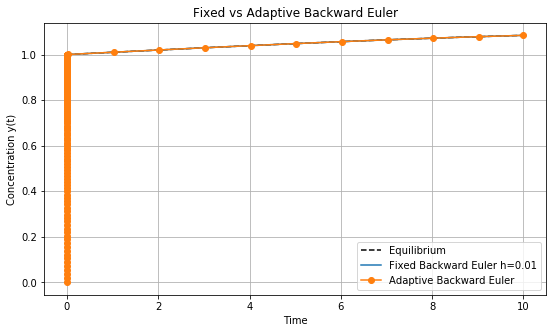

In [7]:
import numpy as np
import matplotlib.pyplot as plt
def backward_euler_fixed(h):
    t_vals = np.arange(t0, tf + h, h)
    y_vals = np.zeros(len(t_vals))
    y_vals[0] = y0

    total_iterations = 0

    for i in range(len(t_vals)-1):
        y_vals[i+1], info = backward_euler_single_step(
            y_vals[i], t_vals[i], h, use_damping=True
        )
        total_iterations += info["iterations"]

    return t_vals, y_vals, total_iterations
#fixed step comparison
fixed_h = 0.01

t_fixed, y_fixed, fixed_iterations = backward_euler_fixed(fixed_h)

fixed_error_final = abs(y_fixed[-1] - y_eq(t_fixed[-1]))
adapt_error_final = abs(y_adapt[-1] - y_eq(t_adapt[-1]))

comparison_table = pd.DataFrame({
    "method": ["Fixed Backward Euler", "Adaptive Backward Euler"],
    "step size": [fixed_h, "Adaptive"],
    "accepted steps": [len(t_fixed)-1, stats_adapt["accepted_steps"]],
    "rejected steps": [0, stats_adapt["rejected_steps"]],
    "newton iterations": [fixed_iterations, stats_adapt["nr_iterations"]],
    "final error estimate": [fixed_error_final, adapt_error_final]
})

comparison_table

plt.figure(figsize=(9,5))
plt.plot(t_ref, y_eq(t_ref), 'k--', label="Equilibrium")
plt.plot(t_fixed, y_fixed, label="Fixed Backward Euler h=0.01")
plt.plot(t_adapt, y_adapt, marker='o', label="Adaptive Backward Euler")
plt.title("Fixed vs Adaptive backward Euler")
plt.xlabel("time")
plt.ylabel("concentration y(t)")
plt.legend()
plt.grid(True)
plt.show()

The fixed step method is easier to implement, but it uses the same step size even when the solution is smooth. The adaptive method changes the step size depending on the error estimate. If the error is too large, the step is rejected and repeated with a smaller h. If the error is small, the method can increase h. This makes the adaptive method more flexible and better suited for problems where the solution changes at different rates over time.

#### Section 5: Robustness Testing

The solver was tested using two difficult cases. The first test used a very large initial step size, $h_0 = 1.0$. This checks whether the adaptive solver can recover when the first step size is too large. The second test used a very tight tolerance, $\text{tol} = 10^{-8}$. This checks whether the solver can handle a stricter accuracy requirement.

These tests show whether the adaptive solver fails or adjusts gracefully. A robust solver should reduce the step size when necessary instead of becoming unstable.

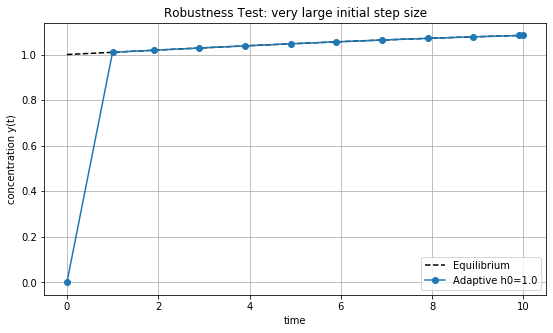

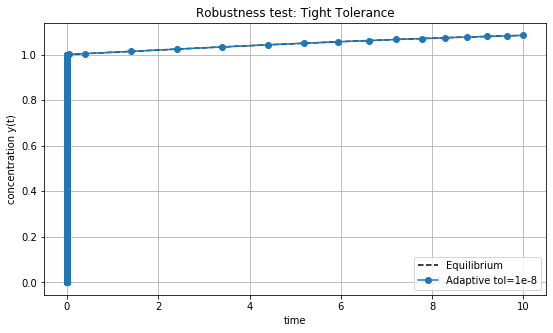

,test,initial h,tolerance,accepted steps,rejected steps,newton iterations,damping used count
0,Large initial h,1.0,1.000000e-04,11,0,66,1
1,Tight tolerance,0.5,1.000000e-08,11199,4,44904,11188


In [12]:
import numpy as np
import matplotlib.pyplot as plt

#test 1: very large initial h
t_large, y_large, h_large, err_large, acc_large, stats_large = adaptive_implicit_euler(
    f, y0, t0, tf, h0=1.0, tol=1e-4, h_min=1e-6, h_max=1.0
)

stats_large

plt.figure(figsize=(9,5))
plt.plot(t_ref, y_eq(t_ref), 'k--', label="Equilibrium")
plt.plot(t_large, y_large, marker='o', label="Adaptive h0=1.0")
plt.title("Robustness Test: very large initial step size")
plt.xlabel("time")
plt.ylabel("concentration y(t)")
plt.legend()
plt.grid(True)
plt.show()

#test 2: very tight tolerance
t_tight, y_tight, h_tight, err_tight, acc_tight, stats_tight = adaptive_implicit_euler(
    f, y0, t0, tf, h0=0.5, tol=1e-8, h_min=1e-8, h_max=1.0
)

stats_tight

plt.figure(figsize=(9,5))
plt.plot(t_ref, y_eq(t_ref), 'k--', label="Equilibrium")
plt.plot(t_tight, y_tight, marker='o', label="Adaptive tol=1e-8")
plt.title("Robustness test: Tight Tolerance")
plt.xlabel("time")
plt.ylabel("concentration y(t)")
plt.legend()
plt.grid(True)
plt.show()

robustness_table = pd.DataFrame({
    "test": ["Large initial h", "Tight tolerance"],
    "initial h": [1.0, 0.5],
    "tolerance": [1e-4, 1e-8],
    "accepted steps": [stats_large["accepted_steps"], stats_tight["accepted_steps"]],
    "rejected steps": [stats_large["rejected_steps"], stats_tight["rejected_steps"]],
    "newton iterations": [stats_large["nr_iterations"], stats_tight["nr_iterations"]],
    "damping used count": [stats_large["damping_used"], stats_tight["damping_used"]]
})

robustness_table

The adaptive solver handled both tests without becoming unstable. For the large initial step size, the solver reduced h when the error was too large. For the tight tolerance, the solver used smaller steps and required more Newton-Raphson iterations. This shows that the method can adjust to both large starting steps and strict accuracy requirements.

#### Section 6: Conclusions

This project extended the Part 2 Backward Euler solver by adding damped Newton-Raphson and adaptive step size control. Damping is most useful when Newton-Raphson might overshoot, especially when the initial guess is poor, the step size is large, or the equation is highly nonlinear. In this chemical reaction problem, damping was not always needed because the residual equation was linear, but adding damping still made the method more robust.

Adaptive step size control is useful when the solution changes quickly in some regions and slowly in others. Instead of using one fixed step size for the entire problem, the adaptive solver automatically reduces h when the error is too large and increases it when the solution is smoother. This helps balance accuracy and computational cost.

The main lesson is that stiff ODEs require careful method selection. Forward Euler can become unstable unless the step size is extremely small, while Backward Euler remains stable for much larger step sizes. Adding damping and adaptive step size control makes the implicit solver safer, more accurate, and more efficient for engineering problems.

Assistance from ChatGPT was used for minor debugging and clarification of implementation details, particularly for structuring the damped Newton-Raphson method and adaptive step size logic.

The AI was used to support understanding and code structure, but the overall implementation and analysis were completed independently.